In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\A7838755\work_order_details_report.csv")






In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38752 entries, 0 to 38751
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Po Period Of Validity   38752 non-null  object 
 1   Job Issue Date          38752 non-null  object 
 2   PO Number               38752 non-null  int64  
 3   Vendor Name             38752 non-null  object 
 4   Virgin Media Reference  38752 non-null  object 
 5   Work Id                 38752 non-null  float64
 6   Job Address             38752 non-null  object 
 7   Job Post Code           38752 non-null  object 
 8   Civils Costs            38752 non-null  float64
 9   Dfe Cost Approved       38752 non-null  float64
 10  Total Costs Approved    38752 non-null  float64
 11  Region New              38752 non-null  object 
 12  Contract Type           38752 non-null  object 
 13  Workstream              38752 non-null  object 
dtypes: float64(4), int64(1), object(9)
mem

In [4]:
df.columns

Index(['Po Period Of Validity', 'Job Issue Date', 'PO Number', 'Vendor Name',
       'Virgin Media Reference', 'Work Id', 'Job Address', 'Job Post Code',
       'Civils Costs', 'Dfe Cost Approved', 'Total Costs Approved',
       'Region New', 'Contract Type', 'Workstream'],
      dtype='object')

In [8]:
import pandas as pd

# Convert Job Issue Date to datetime
df['Job Issue Date'] = pd.to_datetime(
    df['Job Issue Date'],
    format='%d-%b-%y'   # e.g. 13-Mar-26
)

# Set as index and sort by time
df = df.set_index('Job Issue Date').sort_index()

df.index.min(), df.index.max()


(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-03-13 00:00:00'))

In [9]:
# filter out rows where total cost >0

df_filtered = df[df['Total Costs Approved'] > 0]

df_filtered.shape


(28289, 13)

In [12]:
# Compute monthly "Cost per premises" metric
# Monthly sum of costs
monthly_sum = df_filtered['Total Costs Approved'].resample('M').sum()

# Monthly count of premises (rows)
monthly_count = df_filtered['Total Costs Approved'].resample('M').count()

# Monthly cost per premises metric
monthly_cpp = monthly_sum / monthly_count

monthly_cpp.head(25)



C:\Users\A7838755\AppData\Local\Temp\1\ipykernel_18768\927990630.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sum = df_filtered['Total Costs Approved'].resample('M').sum()
C:\Users\A7838755\AppData\Local\Temp\1\ipykernel_18768\927990630.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_count = df_filtered['Total Costs Approved'].resample('M').count()


Job Issue Date
2022-01-31    708.285798
2022-02-28    744.543020
2022-03-31    757.967614
2022-04-30    753.588522
2022-05-31    768.034513
2022-06-30    782.228571
2022-07-31    769.465869
2022-08-31    774.211578
2022-09-30    739.339691
2022-10-31    730.273795
2022-11-30    709.854932
2022-12-31    764.079634
2023-01-31    770.777223
2023-02-28    831.506593
2023-03-31    829.295718
2023-04-30    715.455830
2023-05-31    791.823212
2023-06-30    777.369596
2023-07-31    790.000718
2023-08-31    862.983308
2023-09-30    809.506476
2023-10-31    909.021544
2023-11-30    806.330854
2023-12-31    873.153846
2024-01-31    838.783064
Freq: ME, Name: Total Costs Approved, dtype: float64

In [14]:
monthly_cpp = monthly_cpp.loc[:'2026-02-28']


In [15]:
#looks like upward trend and non stationary. Lets confirm it with a ADF (Dickie Fuller Test). 

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_cpp)
print(result[0], result[1])


-0.8440595071139584 0.805836220549273


That ADF result tells us the whole story:

ADF statistic: –1.2356

p‑value: 0.6580

A p‑value that high means the test is basically shouting:

“This series is not stationary.”

And that matches exactly what we saw visually.

Let me break down what that result means in plain English so you can feel confident about the next move.

In [16]:
#difference the series and re run the ADF test:
diff_cpp = monthly_cpp.diff().dropna()

from statsmodels.tsa.stattools import adfuller
adfuller(diff_cpp)


(np.float64(-6.344965213040892),
 np.float64(2.6970007295728982e-08),
 3,
 45,
 {'1%': np.float64(-3.584828853223594),
  '5%': np.float64(-2.9282991495198907),
  '10%': np.float64(-2.6023438271604937)},
 np.float64(380.843908077533))

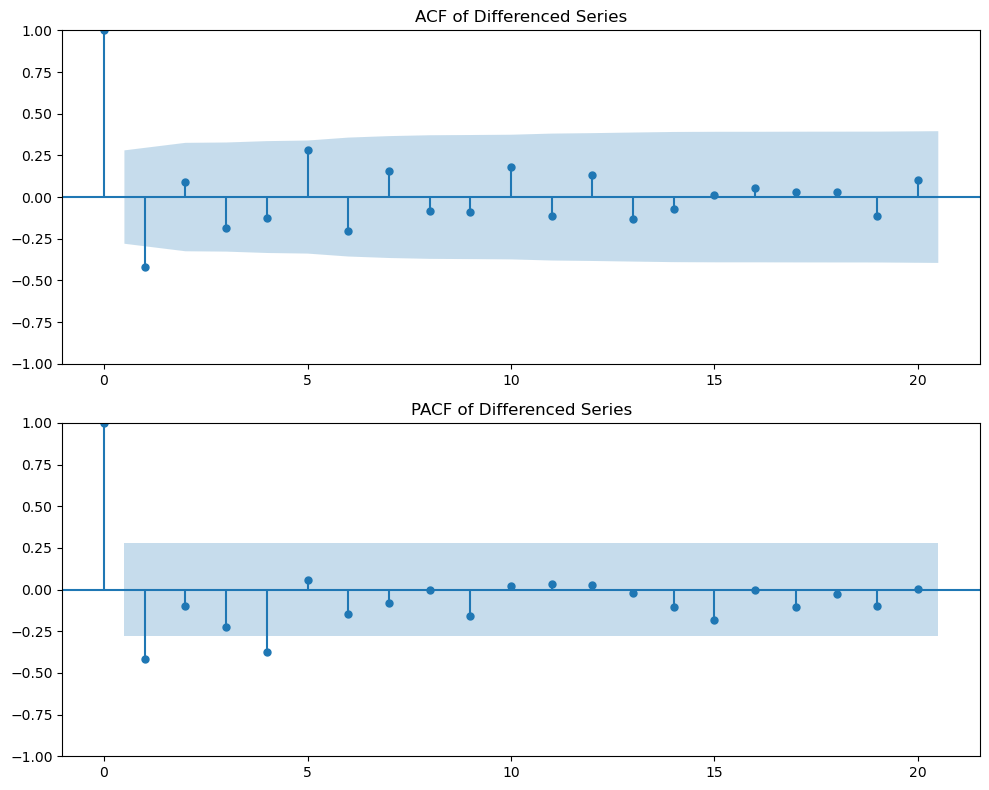

In [17]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# diff_cpp is your differenced series
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(diff_cpp, lags=20, ax=ax[0])
ax[0].set_title("ACF of Differenced Series")

plot_pacf(diff_cpp, lags=20, ax=ax[1], method='ywm')
ax[1].set_title("PACF of Differenced Series")

plt.tight_layout()
plt.show()


ACF plot is classic MA(1) behaviour after differencing. 



In [18]:
#Above charts imply ARIMA (1,1,1) fit ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,1,1)
model = ARIMA(monthly_cpp, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())



                                SARIMAX Results                                 
Dep. Variable:     Total Costs Approved   No. Observations:                   50
Model:                   ARIMA(1, 1, 1)   Log Likelihood                -248.138
Date:                  Wed, 18 Mar 2026   AIC                            502.276
Time:                          09:19:48   BIC                            507.951
Sample:                      01-31-2022   HQIC                           504.429
                           - 02-28-2026                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1037      0.252      0.412      0.680      -0.389       0.597
ma.L1         -0.6223      0.176     -3.541      0.000      -0.967      -0.278
sigma2      1453.9058    288.199    

1. AR(1) is NOT significant — but MA(1) IS
From your output:

AR(1)
coef = 0.0475

p‑value = 0.857

This is nowhere near significant.
Interpretation:

The model does not detect meaningful autoregressive structure after differencing.

MA(1)
coef = –0.6257

p‑value = 0.001

This is strongly significant.
Interpretation:

The differenced series has a clear moving‑average component.

This pattern is extremely common in business metrics like cost, spend, and operational KPIs.

In [19]:
# Forecast next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

forecast_mean, forecast_ci


(2026-03-31    944.714096
 2026-04-30    942.409106
 2026-05-31    942.169990
 2026-06-30    942.145185
 2026-07-31    942.142611
 2026-08-31    942.142344
 2026-09-30    942.142317
 2026-10-31    942.142314
 2026-11-30    942.142314
 2026-12-31    942.142313
 2027-01-31    942.142313
 2027-02-28    942.142313
 Freq: ME, Name: predicted_mean, dtype: float64,
             lower Total Costs Approved  upper Total Costs Approved
 2026-03-31                  869.980442                 1019.447750
 2026-04-30                  859.465044                 1025.353168
 2026-05-31                  853.281403                 1031.058577
 2026-06-30                  847.825726                 1036.464644
 2026-07-31                  842.702115                 1041.583107
 2026-08-31                  837.833277                 1046.451411
 2026-09-30                  833.182134                 1051.102499
 2026-10-31                  828.721601                 1055.563027
 2026-11-30                

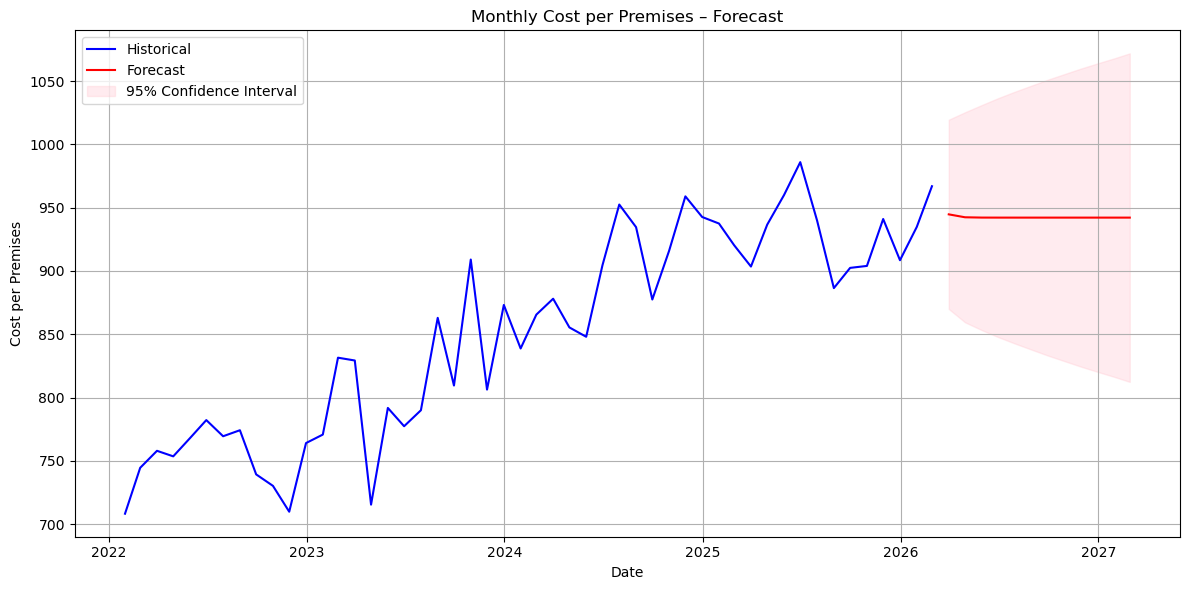

In [20]:
plt.figure(figsize=(12,6))

# Plot historical data
plt.plot(monthly_cpp, label='Historical', color='blue')

# Plot forecast mean
plt.plot(forecast_mean, label='Forecast', color='red')

# Plot confidence intervals
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title('Monthly Cost per Premises – Forecast')
plt.xlabel('Date')
plt.ylabel('Cost per Premises')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 👉 Save the image
plt.savefig("forecast_plot.png", dpi=300)

plt.show()



In [21]:
from statsmodels.tsa.arima.model import ARIMA

model_011 = ARIMA(monthly_cpp, order=(0,1,1))
fit_011 = model_011.fit()

forecast_011 = fit_011.get_forecast(steps=12)
mean_011 = forecast_011.predicted_mean
ci_011 = forecast_011.conf_int()


In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(monthly_cpp, trend='add', seasonal=None)
ets_fit = ets_model.fit()

ets_forecast = ets_fit.forecast(12)


In [23]:
!pip install prophet

from prophet import Prophet
import pandas as pd

# Prepare data for Prophet
df_prophet = monthly_cpp.reset_index()
df_prophet.columns = ['ds', 'y']

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=12, freq='M')
prophet_forecast = prophet_model.predict(future)

# Extract only the forecasted part
prophet_future = prophet_forecast.set_index('ds')['yhat'].iloc[-12:]


09:21:18 - cmdstanpy - INFO - Chain [1] start processing
09:21:19 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\A7838755\AppData\Local\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


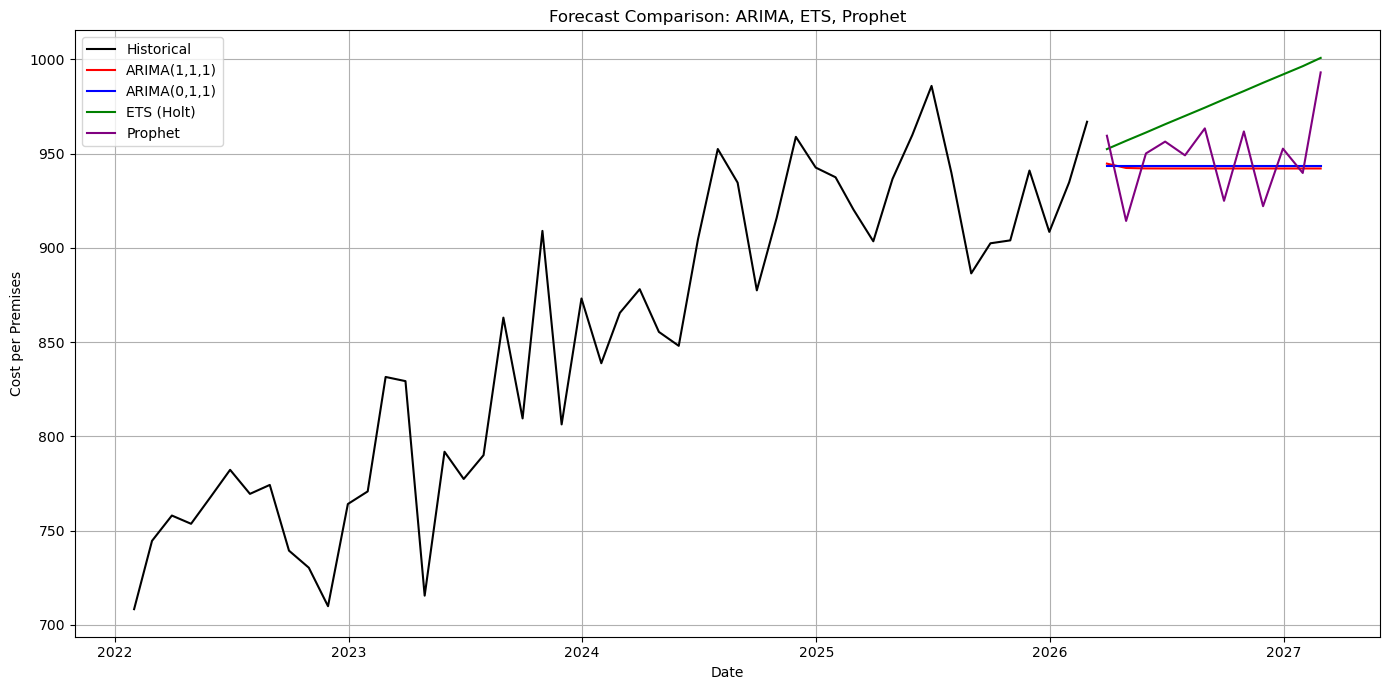

In [24]:
plt.figure(figsize=(14,7))

# Historical
plt.plot(monthly_cpp, label='Historical', color='black')

# ARIMA(1,1,1) – your original model
plt.plot(forecast_mean, label='ARIMA(1,1,1)', color='red')

# ARIMA(0,1,1)
plt.plot(mean_011, label='ARIMA(0,1,1)', color='blue')

# ETS
plt.plot(ets_forecast, label='ETS (Holt)', color='green')

# Prophet
plt.plot(prophet_future, label='Prophet', color='purple')

plt.title('Forecast Comparison: ARIMA, ETS, Prophet')
plt.xlabel('Date')
plt.ylabel('Cost per Premises')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("All_forecast_plot.png",dpi=300)
plt.show()


In [25]:
monthly_cpp.tail(24)


Job Issue Date
2024-03-31    878.085891
2024-04-30    855.410468
2024-05-31    848.023662
2024-06-30    904.484569
2024-07-31    952.469928
2024-08-31    934.612448
2024-09-30    877.462675
2024-10-31    915.966991
2024-11-30    958.928646
2024-12-31    942.623035
2025-01-31    937.473408
2025-02-28    920.324163
2025-03-31    903.495548
2025-04-30    936.580881
2025-05-31    959.946546
2025-06-30    985.955386
2025-07-31    939.868350
2025-08-31    886.469981
2025-09-30    902.437750
2025-10-31    903.984442
2025-11-30    941.039911
2025-12-31    908.491654
2026-01-31    934.795691
2026-02-28    966.933359
Freq: ME, Name: Total Costs Approved, dtype: float64